# Task 1 – Building the DFN model and choosing a parameter set

I wanted to find the best starting point for the parameters.
A DFN model has 40+ parameters (electrode thickness, particle size, diffusivities, OCP curves,
kinetics...) and measuring all of them needs a cell teardown, which I don't have.
So the practical approach is to start from a published parameter set that is as close as
possible to our cell (A123 ANR26650M1B, LFP/graphite, 26650 cylindrical, 2.5 Ah), and then
tune it with our own test data in the later tasks, this is my initial plan

My approch on selection criteria are:
1. **Same chemistry**: LFP cathode + graphite anode. 
2. **Similar cell, or at least the same format** (A123 26650  possible of this size/format/chemsitry).
3. **Full DFN parameter set** 

##  Literature survey – what parameter sets are out there?

**Step 1: PyBaMM built-in parameter sets.**


**Step 2: other open sources trustable I looked at.**

|  | Source | Cell  |
|---|--------|------|
| 1 | **Prada et al. 2013**, J. Electrochem. Soc. 160(4) A616, doi:10.1149/2.053304jes | A123 ANR26650M1 (LFP/graphite, 2.3 Ah) |
| 2 | **About:Energy LFP 18650** (BPX format, Faraday Institution BPX repo, Dec 2022) | LFP/graphite 18650, 2 Ah   |
| 3 | **Forman et al. 2012**, J. Power Sources 210, 263–275 | Commercial 2.3 Ah 26650 LFP cell |
| 4 | **Safari & Delacourt 2011**, J. Electrochem. Soc. 158(5) A562 | Commercial graphite/LFP cell |
| 5 | **LiionDB** (Wang et al. 2022, Prog. Energy, doi:10.1088/2516-1083/ac692c) | Database, many cells|

**Decision: I chose Prada2013 as the baseline.**
**Known gaps in Prada2013 that I found while reading the PyBaMM source file:**
- It is built for the **2.3 Ah** ANR26650M1, but our M1B cell is **2.5 Ah**, so capacity-related
  parameters will need adjusting.

So Prada2013 is a reasonable starting point, but later it to need tuning.

## Import library

In [1]:
# Import the libraries we need
import pybamm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import gc
from scipy.optimize import brentq

print("PyBaMM version:", pybamm.__version__)

PyBaMM version: 25.12.2


## List of all Parameters sets avaibale in Pybamm

In [2]:
# See which parameter sets come with PyBaMM
all_sets = list(pybamm.parameter_sets)
print(all_sets)

['Ai2020', 'Chayambuka2022', 'Chen2020', 'Chen2020_composite', 'ECM_Example', 'Ecker2015', 'Ecker2015_graphite_halfcell', 'MSMR_Example', 'Marquis2019', 'Mohtat2020', 'NCA_Kim2011', 'OKane2022', 'OKane2022_graphite_SiOx_halfcell', 'ORegan2022', 'Prada2013', 'Ramadass2004', 'Sulzer2019', 'Xu2019']


##### Since Prada2013 parameter set belongs to same format/size/chemistry of cell/battery, we start with Prada2013 parameters

## List of all Parameters of Prada2013

In [3]:
import pybamm
import pandas as pd

# Load the Prada2013 parameter set
param = pybamm.ParameterValues("Prada2013")

# Show all rows/text in the notebook
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

# Go through every parameter and put it in a table
rows = []
for name, value in param.items():
    if name == "citations":          
        continue
    if callable(value):              
        rows.append([name, "function", value.__name__])
    else:                            
        rows.append([name, "constant", f"{value:.4g}"])

prada_df = pd.DataFrame(rows, columns=["Parameter", "Type", "Value"])

# Print the table
print(prada_df)

                                                    Parameter      Type  \
0                            Negative electrode thickness [m]  constant   
1                                     Separator thickness [m]  constant   
2                            Positive electrode thickness [m]  constant   
3                                        Electrode height [m]  constant   
4                                         Electrode width [m]  constant   
5                                 Nominal cell capacity [A.h]  constant   
6                                        Current function [A]  constant   
7                                    Contact resistance [Ohm]  constant   
8                     Negative electrode conductivity [S.m-1]  constant   
9       Maximum concentration in negative electrode [mol.m-3]  constant   
10                     Negative particle diffusivity [m2.s-1]  constant   
11                                 Negative electrode OCP [V]  function   
12                       

## we start with looking into given HPPC data.

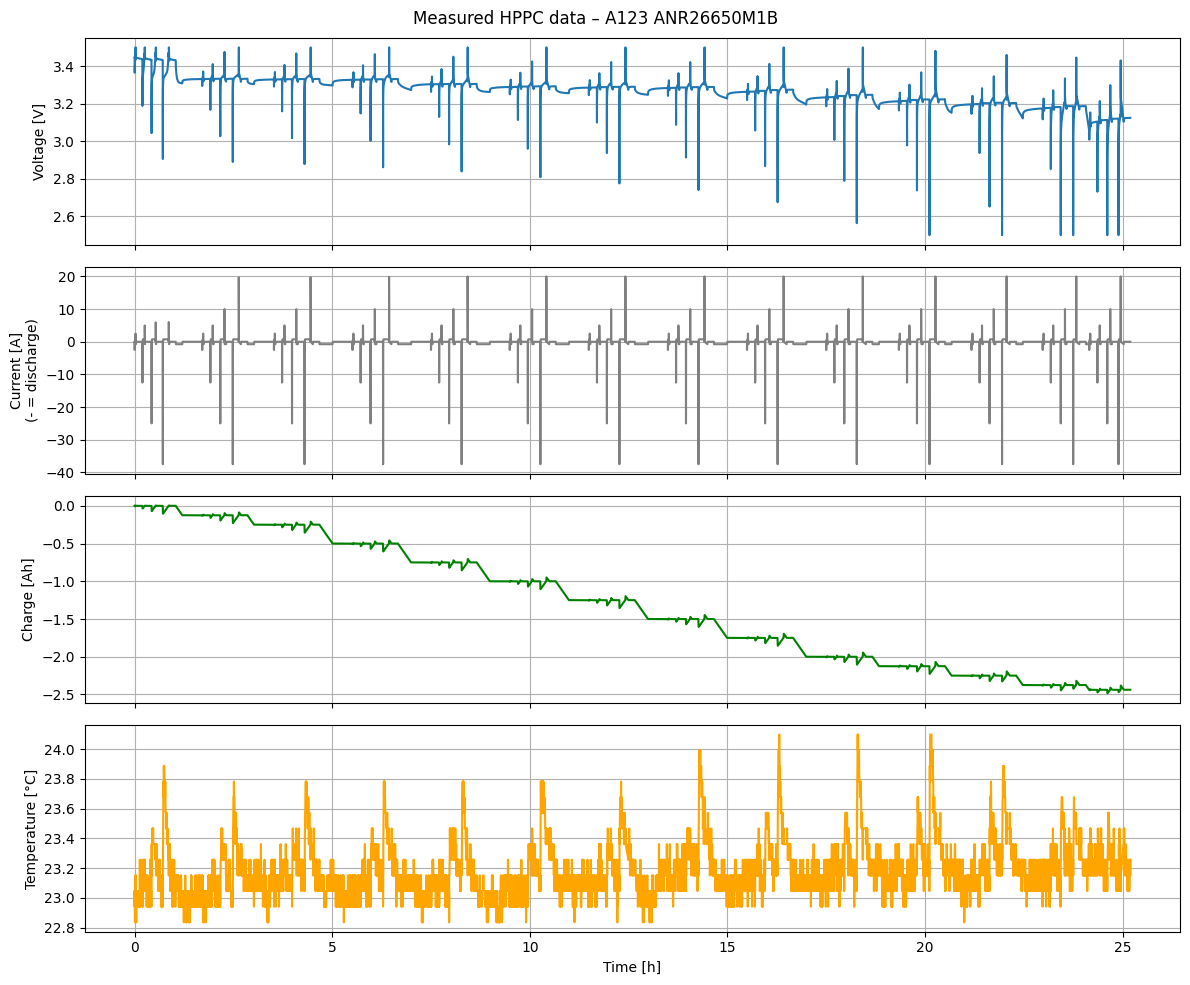

In [4]:
meas = sio.loadmat(r"K:\chalmers\DML\deep-machine-learning\Pybamm_DFN\lfp_dfn\Data_dir\HPPC.mat",
                   squeeze_me=True, struct_as_record=False)["meas"]

t_h = (meas.Time - meas.Time[0]) / 3600    # time in hours

fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

ax[0].plot(t_h, meas.Voltage)
ax[0].set_ylabel("Voltage [V]")

ax[1].plot(t_h, meas.Current, color="gray")
ax[1].set_ylabel("Current [A]\n(- = discharge)")

ax[2].plot(t_h, meas.Ah, color="green")
ax[2].set_ylabel("Charge [Ah]")

ax[3].plot(t_h, meas.Battery_Temp_degC, color="orange")
ax[3].set_ylabel("Temperature [°C]")
ax[3].set_xlabel("Time [h]")

for a in ax:
    a.grid(True)
plt.suptitle("Measured HPPC data – A123 ANR26650M1B")
plt.tight_layout()
plt.savefig("hppc_measured_data.png", dpi=150)
plt.show()

##  Model setup

# Task 2 – Simulating the HPPC test with the baseline (Prada2013) model

with  requirment settings

Here I take the measured current from the HPPC test given, feed it into the DFN model with the
Prada2013 parameters, and compare the simulated voltage with the measured voltage.
This gives me the **baseline error**

Initial SOC used : 1.0
Stop reason      : event: Minimum voltage [V]
Simulated        : 16.27 h of 25.20 h


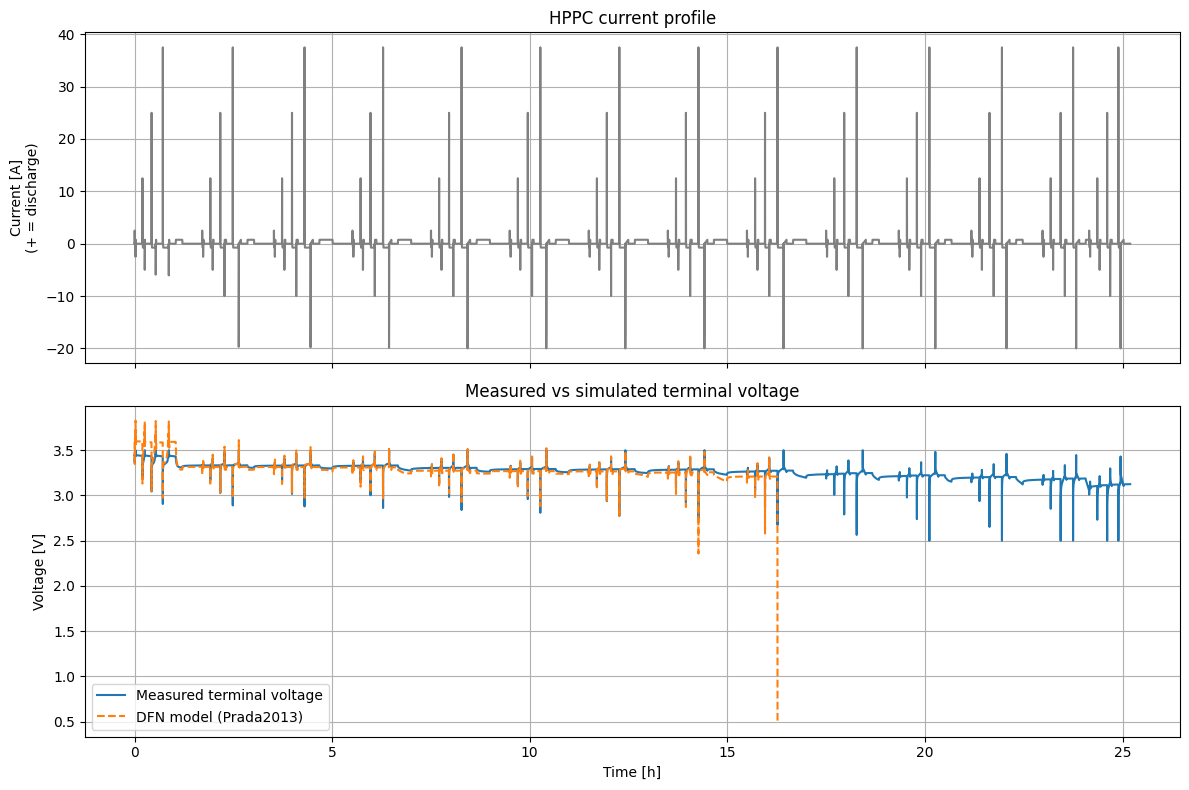

In [5]:
# ---- HPPC data ----
# (Assuming 'meas' dataframe is already defined in your environment)
t, idx = np.unique(meas.Time - meas.Time[0], return_index=True)   # time from 0 s, no duplicate time stamps
I = -meas.Current[idx]      # PyBaMM: + = discharge (data: - = discharge)
V = meas.Voltage[idx]

# ---- Prada2013 parameters ----
param = pybamm.ParameterValues("Prada2013")
param["Nominal cell capacity [A.h]"] = 2.5                           # A123 ANR26650M1B
param["Current function [A]"] = pybamm.Interpolant(t, I, pybamm.t)   # HPPC current profile
param["Upper voltage cut-off [V]"] = 4.2                             # wider limits so short pulses don't stop the run
param["Lower voltage cut-off [V]"] = 0.5
param["Ambient temperature [K]"] = 298.15                            # test at ~23 °C
param["Initial temperature [K]"] = 298.15

# ---- DFN model ----
model = pybamm.lithium_ion.DFN()
sim = pybamm.Simulation(model, parameter_values=param)

# ---- Simulate the HPPC current ----
# Start fully charged; if a charge pulse at 100% SOC pushes the model over the limit, start slightly lower
for soc in [1.0]:
    sol = sim.solve(t_eval=t, initial_soc=soc)
    if "Maximum voltage" not in sol.termination:
        break

print(f"Initial SOC used : {soc}")
print(f"Stop reason      : {sol.termination}")
print(f"Simulated        : {sol['Time [s]'].entries[-1]/3600:.2f} h of {t[-1]/3600:.2f} h")

# ---- Plotting ----
t_sim = sol["Time [s]"].entries
V_sim = sol["Voltage [V]"].entries

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: HPPC current profile
ax[0].plot(t / 3600, I, color="gray")
ax[0].set_ylabel("Current [A]\n(+ = discharge)")
ax[0].set_title("HPPC current profile")

# Bottom: measured terminal voltage vs model output
ax[1].plot(t / 3600, V, label="Measured terminal voltage")
ax[1].plot(t_sim / 3600, V_sim, "--", label="DFN model (Prada2013)")
#ax[1].axvline(t_sim[-1] / 3600, color="black", linestyle=":", label="Model stopped")
ax[1].set_ylabel("Voltage [V]")
ax[1].set_xlabel("Time [h]")
ax[1].set_title("Measured vs simulated terminal voltage")
ax[1].legend()

for a in ax:
    a.grid(True)
    
plt.tight_layout()
plt.savefig("task2_hppc_measured_vs_model.png", dpi=150)
plt.show()

## Manuval Tuning 
Task 2 part-b
Here we adjusted electrode stoichimetry and electrode diffusivity

Stop reason : final time
Simulated   : 25.20 h of 25.20 h
RMSE        : 39.4 mV
Min graphite surface stoichiometry: 0.062


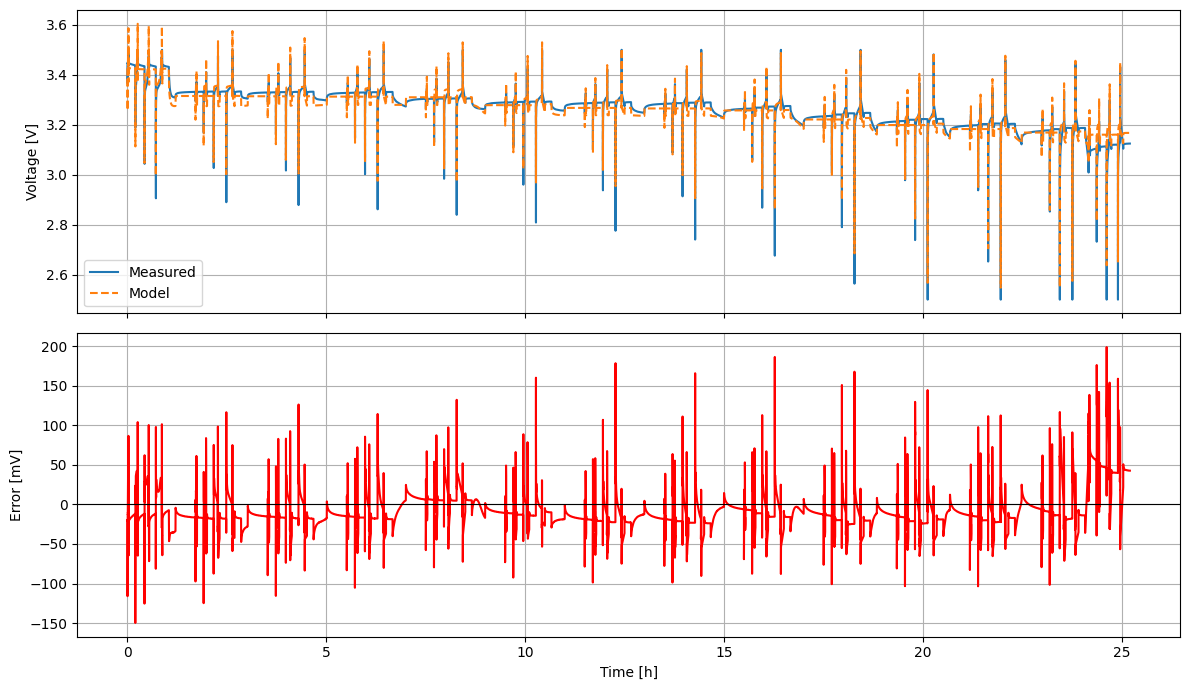

33630

In [6]:
# ---- HPPC data ----
t, idx = np.unique(meas.Time - meas.Time[0], return_index=True)
I = -meas.Current[idx]      # PyBaMM: + = discharge
V = meas.Voltage[idx]

# =====================================================================
# ---- KNOBS: original Prada2013 values - change and re-run ----
x100      = 0.9082      # graphite stoichiometry at 100% SOC        -> capacity / voltage level
y100      = 0.01    # LFP stoichiometry at 100% SOC             -> voltage at full charge

D_n       = 1.5e-14     # graphite particle diffusivity [m2/s]   -> pulse sag / collapse
D_p       = 5.8e-18   # LFP particle diffusivity [m2/s]           -> pulse sag / relaxation



k_j0_n    = 1.0       # x graphite reaction rate (function, so a multiplier) -> pulse voltage drop
k_j0_p    = 1.0       # x LFP reaction rate (function, so a multiplier)      -> pulse voltage dropww
T_C       = 23.0      # test temperature [°C]
# =====================================================================

param = pybamm.ParameterValues("Prada2013")
param["Nominal cell capacity [A.h]"] = 2.5
param["Current function [A]"] = pybamm.Interpolant(t, I, pybamm.t)
param["Upper voltage cut-off [V]"] = 4.2
param["Lower voltage cut-off [V]"] = 1
param["Ambient temperature [K]"] = 273.15 + T_C
param["Initial temperature [K]"] = 273.15 + T_C

# Stoichiometry window (starting state = full cell)
param["Initial concentration in negative electrode [mol.m-3]"] = x100 * param["Maximum concentration in negative electrode [mol.m-3]"]
param["Initial concentration in positive electrode [mol.m-3]"] = y100 * param["Maximum concentration in positive electrode [mol.m-3]"]

# Direct values
param["Negative particle diffusivity [m2.s-1]"] = D_n
param["Positive particle diffusivity [m2.s-1]"] = D_p

# Reaction rates (functions -> scaled by a multiplier)
j0_n = param["Negative electrode exchange-current density [A.m-2]"]
j0_p = param["Positive electrode exchange-current density [A.m-2]"]
param["Negative electrode exchange-current density [A.m-2]"] = lambda c_e, c_s_surf, c_s_max, T: k_j0_n * j0_n(c_e, c_s_surf, c_s_max, T)
param["Positive electrode exchange-current density [A.m-2]"] = lambda c_e, c_s_surf, c_s_max, T: k_j0_p * j0_p(c_e, c_s_surf, c_s_max, T)

# Physical check: active material + porosity must be < 1
for e in ["Negative", "Positive"]:
    total = param[f"{e} electrode active material volume fraction"] + param[f"{e} electrode porosity"]
    if total >= 1:
        print(f"WARNING: {e} active fraction + porosity = {total:.3f} (must be < 1)")

# ---- Simulate: keep only the variables we need (saves a lot of memory) ----
solver = pybamm.IDAKLUSolver(output_variables=["Voltage [V]", "Negative particle surface stoichiometry"])
sim = pybamm.Simulation(pybamm.lithium_ion.DFN(), parameter_values=param, solver=solver)
sol = sim.solve(t_eval=t)

t_sim  = sol.t
V_sim  = sol["Voltage [V]"].entries
x_surf = sol["Negative particle surface stoichiometry"].entries.min()
stop   = sol.termination

mask  = t <= t_sim[-1]
error = np.interp(t[mask], t_sim, V_sim) - V[mask]

print(f"Stop reason : {stop}")
print(f"Simulated   : {t_sim[-1]/3600:.2f} h of {t[-1]/3600:.2f} h")
print(f"RMSE        : {np.sqrt(np.mean(error**2))*1000:.1f} mV")
print(f"Min graphite surface stoichiometry: {x_surf:.3f}")

# ---- Plot ----
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(t / 3600, V, label="Measured")
ax[0].plot(t_sim / 3600, V_sim, "--", label="Model")
ax[0].set_ylabel("Voltage [V]")
ax[0].legend()
ax[1].plot(t[mask] / 3600, error * 1000, color="red")
ax[1].axhline(0, color="black", linewidth=0.8)
ax[1].set_ylabel("Error [mV]")
ax[1].set_xlabel("Time [h]")
for a in ax:
    a.grid(True)
plt.tight_layout()
plt.show()

# ---- Free memory ----
plt.close(fig)
del sim, sol, solver, param
gc.collect()

### Error metrics and why they were chosen

The simulated voltage is compared with the measured HPPC voltage at every measured time point. If the model stops early, only the part it simulated is used.

**Main metric: RMSE (root mean square error)**
RMSE = √( mean( (V_model − V_meas)² ) )
- It has the same unit as voltage (mV), so it is easy to read
- It is the standard metric in battery-model papers, and it matches the least-squares objective used later for the parameter optimization (Task 4).

MAPE and R² were not used. The voltage level (about 3.3 V) and the large voltage range of the full test make them look good even when the pulses are fitted poorly.